In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/prathamtripathi/regression-with-neural-networking/concrete_data.csv


In [2]:
df=pd.read_csv('/kaggle/input/datasets/prathamtripathi/regression-with-neural-networking/concrete_data.csv')

In [3]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.iloc[:,0:8],df.iloc[:,-1],test_size=0.25,random_state=45 )

In [5]:
from sklearn.preprocessing import StandardScaler
st=StandardScaler()
st.fit(x_train)
x_train_scaled=st.transform(x_train)
x_test_scaled=st.transform(x_test)
st.mean_

array([284.38834197,  73.82176166,  53.5265544 , 181.29326425,
         6.15699482, 973.39494819, 772.91321244,  43.61787565])

In [6]:
from sklearn.linear_model import LinearRegression
import seaborn as sns
import numpy as np
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score 
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer 
lr=LinearRegression()
lr.fit(x_train_scaled,y_train)
y_prd=lr.predict(x_test_scaled )
from sklearn.metrics import r2_score 
r2_score(y_test,y_prd)

0.5907451281595038

In [7]:
print(r2_score(y_test, y_prd))

0.5907451281595038


In [8]:
pt=PowerTransformer(method='box-cox')

x_train_trn=pt.fit_transform(x_train+0.00000001)
x_test_trn=pt.fit_transform(x_test+0.00000001)
pd.DataFrame({'cols': x_train.columns,'box_cox_lambdas': pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,-0.025429
1,Blast Furnace Slag,0.013114
2,Fly Ash,-0.020309
3,Water,1.049472
4,Superplasticizer,0.083371
5,Coarse Aggregate,1.067006
6,Fine Aggregate,1.474598
7,Age,0.026608


In [9]:
lr=LinearRegression()
lr.fit(x_train_trn,y_train)
y_prd=lr.predict(x_test_trn )
from sklearn.metrics import r2_score 
r2_score(y_test,y_prd)

0.7798216185840272

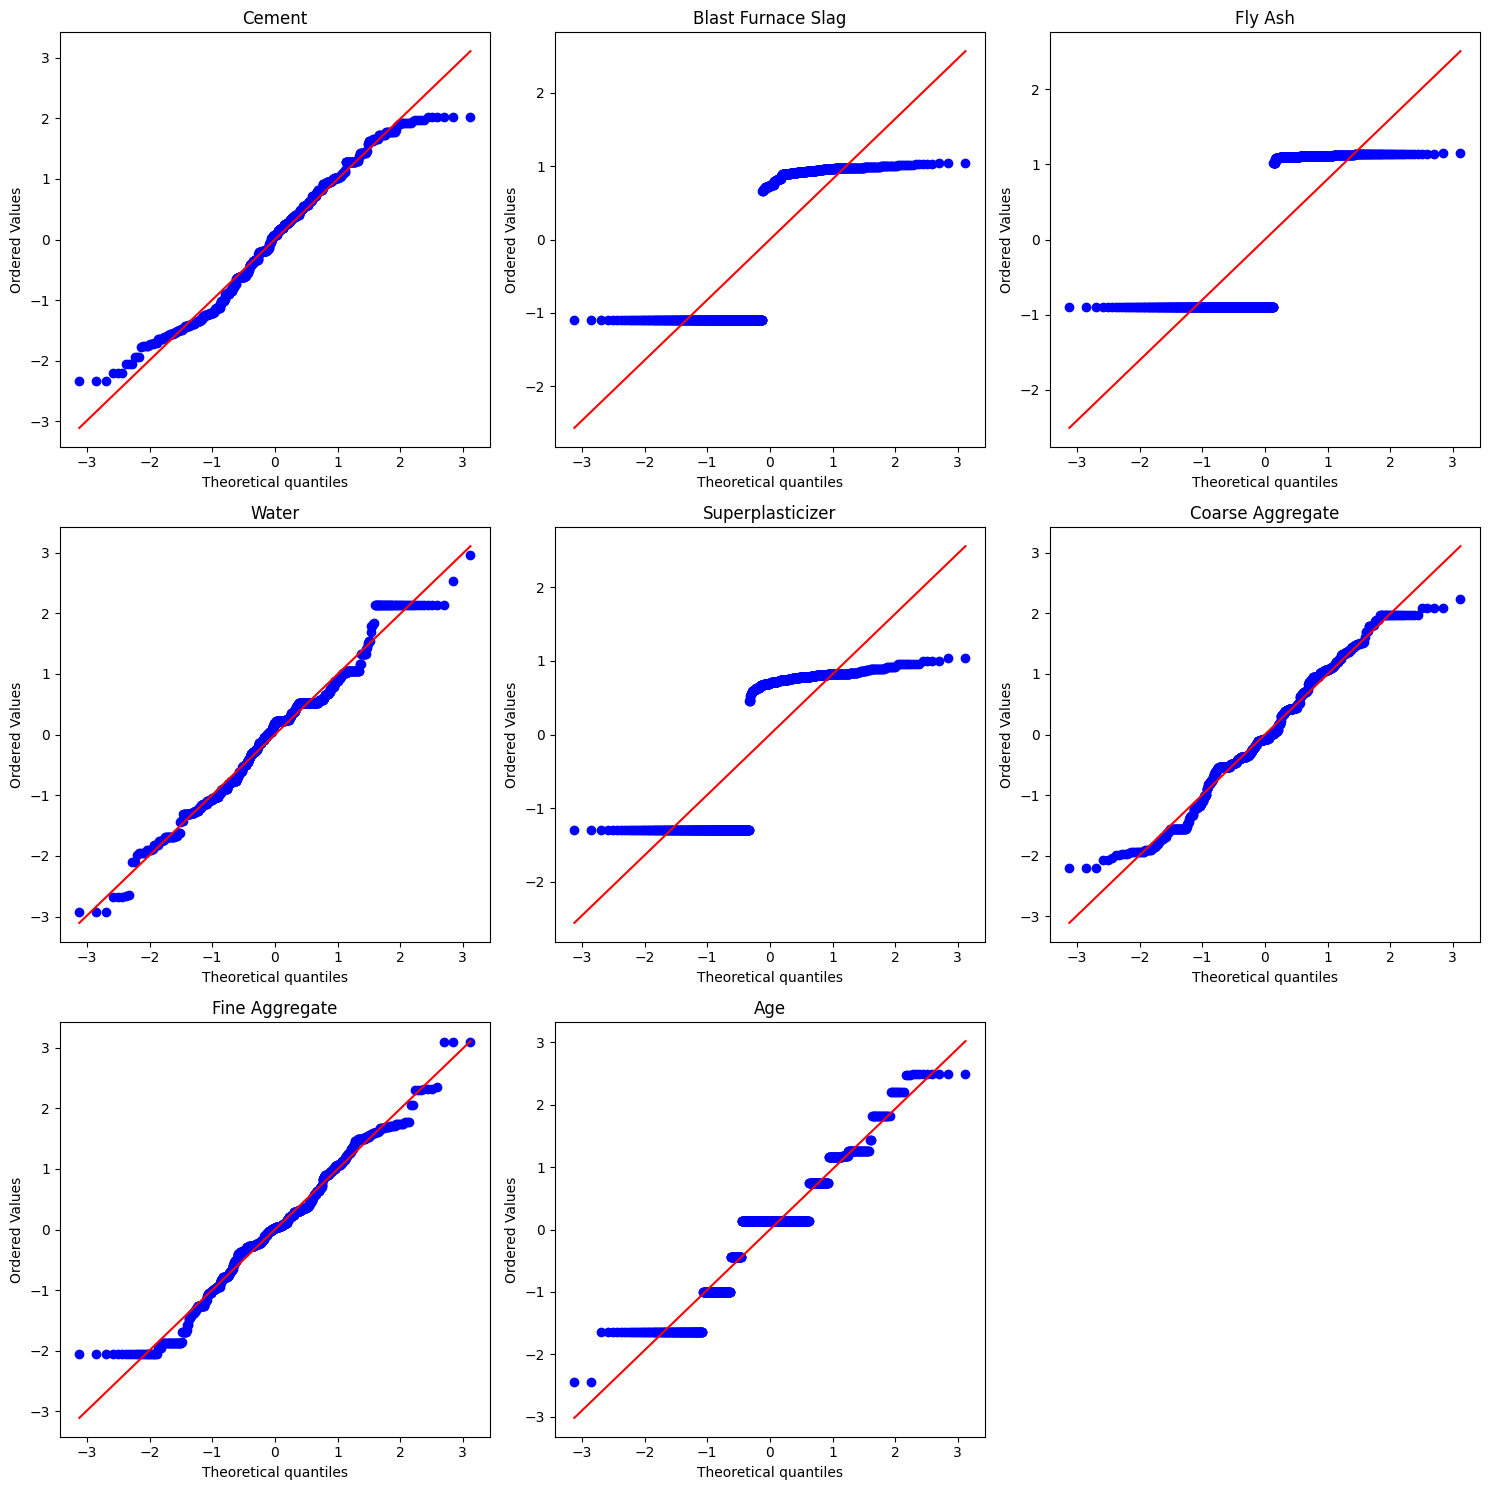

In [10]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

col_names = df.columns[:-1]

n_features = x_train_trn.shape[1]

n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(col_names):
    stats.probplot(x_train_trn[:, i], dist="norm", plot=axes[i])
    axes[i].set_title(col)

for j in range(len(col_names), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [11]:
pt=PowerTransformer(method='yeo-johnson')

x_train_trnyj=pt.fit_transform(x_train+0.00000001)
x_test_trnyj=pt.fit_transform(x_test+0.00000001)
pd.DataFrame({'cols': x_train.columns,'Yeo_Johnson_lambdas': pt.lambdas_,"box_cox_lambdas":pt.lambdas_})

,cols,Yeo_Johnson_lambdas,box_cox_lambdas
0,Cement,-0.028940,-0.028940
1,Blast Furnace Slag,-0.001055,-0.001055
2,Fly Ash,-0.113576,-0.113576
3,Water,1.049568,1.049568
4,Superplasticizer,0.266721,0.266721
5,Coarse Aggregate,1.067184,1.067184
6,Fine Aggregate,1.475228,1.475228
7,Age,-0.018713,-0.018713


In [12]:
lr=LinearRegression()
lr.fit(x_train_trnyj,y_train)
y_prd=lr.predict(x_test_trnyj )
from sklearn.metrics import r2_score 
r2_score(y_test,y_prd)

0.7881080796330446